## Premiação de Melhor Filme no Oscar - Polymarket no BigQuery

### Introdução

*Pergunta Central:* Como os resultados de premiações precursoras (Globo de Ouro, BAFTA, SAG...) e o volume de negociação impactam a probabilidade percebida (preço das ações) de um filme na campanha do Oscar?

*Hipótese Inicial:* Grandes deslocamentos de preço (reprecificações abruptas da probabilidade) não ocorrem de forma linear, mas sim em saltos concentrados em janelas ao redor do anúncio de prêmios precursores. Além disso, picos anômalos de volume antecedem ou acompanham diretamente esses saltos de preço.



In [1]:
# Configuração do notebook
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Definição paleta de cores
COR_BANDA = "#93c5fd"     
COR_PRECO = "#2563eb"     
COR_DESTAQUE = "#ea580c"  
COR_VOLUME = "#9ca3af"    

# Definição da pasta raiz de dados
DADOS_DIR = Path("dados")

def carrega(nome_relativo, base_dir=DADOS_DIR, colunas_data=("created_at", "end_date")):
    '''Lê CSV exportado do BigQuery resolvendo o caminho dinamicamente.'''
    caminho_completo = Path(base_dir) / nome_relativo
    if not caminho_completo.is_file():
        raise FileNotFoundError(f"Arquivo não encontrado em: {caminho_completo.resolve()}")

    df = pd.read_csv(caminho_completo)

    # Conversão explícita por nome, não por adivinhação de sufixo.
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
            n_falhas = df[col].isna().sum()
            if n_falhas:
                print(f"Aviso: {n_falhas} valores de '{col}' não converteram em {nome_relativo}")

    return df

### Etapa 1: Quais os mercados de premiações de filmes?

Para descobrir como funcionam os mercados de premiações no polymarket, decidimos buscar por um dos filmes mais reconhecidos pela academia na temporada de 2025: The Brutalist, a fim de facilitar a compreensão dos mercados existentes em torno de uma única obra.

In [ ]:
-- Q1: como aparecem os mercados de The Brutalist
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%the brutalist%'
ORDER BY volume DESC
LIMIT 20;


In [2]:
q1 = carrega("exploracao_inicial/the_brutalist.csv")

q1["dias_de_vida"] = (q1["end_date"] - q1["created_at"]).dt.days
q1[["question", "event_title", "volume", "dias_de_vida"]]

q1[["market_id","question", "event_title", "volume", "dias_de_vida"]].head(11)

,market_id,question,event_title,volume,dias_de_vida
0,519437,"Will ""The Brutalist"" win Best Picture at the 2...",Oscars: Best Picture,584985.915884,39
1,522986,"Will ""The Brutalist"" win Best Film at the 2025...",BAFTA Award: Best Film,253931.546846,4
2,520205,"Will ""The Brutalist"" win Best Original Screenp...",Oscars: Best Original Screenplay,112985.526352,36
3,520210,Will Brady Corbet win Best Director at the 202...,Oscars: Best Director,77896.555406,36
4,515933,Will 'The Brutalist' win the Golden Globe for ...,Golden Globes: Best Original Score,32069.117642,18
5,524010,"Will ""The Brutalist"" win the most Oscars in th...",Which movie will win the most Oscars?,31274.351928,11
6,522879,Will Adrien Brody win Best Actor at the 2025 S...,SAG Award: Best Actor,21879.648405,11
7,524182,"Will ""The Brutalist"" win Best Original Score a...",Oscars: Best Original Score,18636.932177,10
8,525565,"Will ""The Brutalist"" win Best Cinematography a...",Oscars: Best Cinematography,14350.215435,3
9,524178,"Will ""The Brutalist"" win Best Film Editing at ...",Oscars: Best Film Editing,13568.073084,10


**O que o resultado revela.** Misturados na mesma ordenação por volume, há dois tipos de
mercado sobre uma única obra:

1. **Categoria única, um filme, uma premiação** — a maioria das linhas:
   `"Will 'The Brutalist' win Best Film at the 2025 BAFTA Awards?"`,
   `event_title` = "BAFTA Award: Best Film". Mesma lógica se repete para Oscar
   (Picture, Screenplay, Director, Cinematography, Score, Editing), Globo de Ouro
   (Score, Screenplay), SAG e BAFTA (Actor, Director) e Critics' Choice
   (Cinematography) — o mesmo filme atravessa 5 premiações diferentes com
   `event_title` nomeado de forma distinta em cada uma.

2. **Contagem/agregado, não binário simples** — a família
   `"How many Oscars will 'The Brutalist' win?"` tem 6 mercados irmãos (0, 1, 2, 3, 4-5,
   6+), todos com o **mesmo** `event_title`. Um resultado que não é vitória/derrota, mas uma partição de
   probabilidade em faixas mutuamente exclusivas.

Primeiro, o volume cai fortemente por relevância de
categoria: Best Picture (US$ 585K) domina sobre categorias técnicas (Cinematography,
Editing, casas dos US$ 13–18K) — sinal de que nem toda categoria vale o mesmo esforço de
análise. Segundo, a data de criação dos mercados segue a ordem cronológica real das
premiações: Globo de Ouro (17/12/2024) → Critics' Choice (04/02/2025) → SAG/BAFTA
(11/02/2025) → Oscar (encerra 02/03/2025).

**Efeito sobre a hipótese.** Esse CSV funciona como uma prova de conceito em miniatura:
mostra que dá para montar, para **um único filme**, uma linha do tempo cruzando todas as
premiações precursoras antes do Oscar. 

**Limitações.** `event_title` não é uma chave estável entre premiações nem entre categorias
do mesmo evento — aparece espaço sobrando em pelo menos duas linhas ("Oscars: Best Original
Screenplay ", "Oscars: Best Film Editing "), reforçando a necessidade de `TRIM()` em
qualquer filtro exato.

### Etapa 2 - Existem mercados suficientes de categoria única em premiação?

In [ ]:
-- Q2A: Tamanho do universo de mercados de categorias únicas
SELECT 
    COUNT(*)                        AS n_mercados,
    ROUND(SUM(volume) / 1e6, 1)     AS volume_total,
    ROUND(AVG(volume), 0)           AS volume_medio
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE "%win best%";

-- Q2B: As 20 indicações mais negociadas (candidatos para estudo)
SELECT
    market_id, question, event_title,
    ROUND(volume, 0) AS volume_usd, created_at, end_date
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE "%win best%"
ORDER BY volume DESC
LIMIT 20;

In [3]:
q2a = carrega("exploracao_inicial/mercados.csv")
q2b = carrega("exploracao_inicial/top_20.csv")
print(q2a.to_string(index=False))

# Janela de vida do mercado: quantos dias antes do jogo ele abre?
q2b["dias_de_vida"] = (q2b["end_date"] - q2b["created_at"]).dt.days
q2b[["market_id", "question", "event_title", "volume_usd", "dias_de_vida"]]

 n_mercados  volume_total  volume_medio
       2407          52.4       21787.0


,market_id,question,event_title,volume_usd,dias_de_vida
0,613841,Will Bugonia win Best Picture at the 98th Acad...,Oscars 2026: Best Picture Winner,3612705.0,169
1,614012,Will Michael B. Jordan win Best Actor at the 9...,Oscars 2026: Best Actor Winner,3149785.0,169
2,613837,Will Sinners win Best Picture at the 98th Acad...,Oscars 2026: Best Picture Winner,2868469.0,169
3,613848,Will Rental Family win Best Picture at the 98t...,Oscars 2026: Best Picture Winner,1079441.0,169
4,613844,Will A House of Dynamite win Best Picture at t...,Oscars 2026: Best Picture Winner,1056888.0,169
5,519436,"Will ""Anora"" win Best Picture at the 2025 Oscars?",Oscars: Best Picture,956469.0,39
6,613843,Will Jay Kelly win Best Picture at the 98th Ac...,Oscars 2026: Best Picture Winner,928427.0,169
7,613846,Will No Other Choice win Best Picture at the 9...,Oscars 2026: Best Picture Winner,826425.0,169
8,613842,Will It Was Just an Accident win Best Picture ...,Oscars 2026: Best Picture Winner,767106.0,169
9,613847,Will Springsteen: Deliver Me from Nowhere win ...,Oscars 2026: Best Picture Winner,755817.0,169


**O que o resultado revela.** O filtro encontra **2.407 mercados**, com **US$ 52,4
milhões** de volume acumulado e média de **US$ 21.787** por mercado.

Os 20 mercados de maior volume **não são só Best Picture** — aparecem também Best Actor
(Michael B. Jordan, US$ 3,15 milhões) e Best Director (Park Chan-wook, Ryan Coogler,
Hikari, Joachim Trier), todos do Oscar 2026. Isso confirma que o filtro `%win best%` está
capturando múltiplas categorias como esperado, mas também significa que qualquer
conclusão sobre "os mercados mais negociados" desse recorte não é automaticamente sobre
Best Picture — precisa de um corte por `event_title` antes de comparar candidatos dentro
da mesma categoria.

`dias_de_vida` aqui não converge para um único valor — ele
se divide em dois grupos claros, alinhados à temporada: os mercados do Oscar 2026 (criados
em 26/09/2025, encerram em 15/03/2026) somam cerca de **170 dias de vida**, enquanto os
mercados do Oscar 2025, que também aparecem no top 20 (Anora, Wicked, The Brutalist, Dune:
Part Two, I'm Still Here — todos criados em 21/01/2025, encerrados em 02/03/2025), somam
apenas **~40 dias**. Ou seja, o Polymarket abriu os mercados da safra 2026 muito mais cedo
em relação à cerimônia do que fez na safra 2025 — um padrão de janela operacional que
mudou de uma temporada para outra, não uma constante do produto.

**Efeito sobre a hipótese.** Há mercados suficientes para escolher candidatos ativos e
depois comparar vários ao mesmo tempo. *Bugonia* (`613841`) lidera a ordenação por volume
do Best Picture 2026, mas liderar o ranking, não necessariamente ser representativo do "mercado típico" da categoria.

**Limitações.** Comparar volume bruto entre mercados de idades tão diferentes (170 dias
vs. 40 dias de vida) favorece os mercados mais antigos/abertos por mais tempo, mesmo que
não sejam mais "populares" por dia de negociação. Além disso, `%win best%` mistura categorias (Picture, Actor, Director) no
mesmo corte — está correto para dimensionar o universo total, mas qualquer leitura sobre
"o candidato mais negociado" precisa isolar por `event_title` antes de comparar
Bugonia com Michael B. Jordan, que competem em categorias diferentes e não são
comparáveis diretamente.

#### Conclusões Analíticas: Dinâmica de Criação e Engajamento dos Mercados

**1. A Ordem de Criação dos Mercados não Segue o Calendário de Premiações**
Diferente da hipótese de que a plataforma Polymarket abre as apostas seguindo a ordem cronológica estrita dos eventos, os dados mostram que a relevância global da premiação dita a antecedência da criação do mercado. Observando a coluna `dias_de_vida`, notamos que o mercado do Oscar (Melhor Filme) apresenta 39 dias de vida no momento do recorte, enquanto mercados que ocorrem semanas antes na vida real, como o BAFTA (Best Film) e o SAG (Best Actor), apresentam apenas 4 e 11 dias de vida, respectivamente. Isso indica que mercados com maior liquidez e apelo popular (Oscar) são abertos dezenas de dias antes dos mercados precursores, atraindo engajamento de longo prazo.

**2. A Ineficiência da Média Diária de Volume**
Para comparar o engajamento entre candidatos de temporadas diferentes (ex: Oscar 2026 com 170 dias de vida vs. Oscar 2025 com 40 dias), a utilização do "volume médio diário" (Volume Total / `dias_de_vida`) mostra-se uma métrica falha. Como estabelecido na nossa hipótese inicial, as negociações em mercados preditivos não ocorrem de forma linear; elas se dão em "saltos" concentrados em janelas de tempo específicas, geralmente ao redor do anúncio de prêmios precursores ou notícias de impacto. Dividir o volume de um mercado de 170 dias pelo seu tempo total de vida diluiria drasticamente os seus picos reais de negociação ao longo de meses de inatividade. Em vez disso, a análise deve se concentrar no **volume transacionado em janelas de D-X e D+X (dias antes e depois)** dos eventos precursores.

### Etapa 3 - Agregações e subqueries de interesse

In [ ]:
-- Etapa 3: Série diária do mercado escolhido
SELECT
  trade_date,
  daily_trade_count,
  ROUND(daily_usd_volume, 2)                  AS volume_usd,
  ROUND(avg_trade_price, 4)                   AS preco_medio,
  ROUND(min_trade_price, 4)                   AS preco_min,
  ROUND(max_trade_price, 4)                   AS preco_max,
  ROUND(max_trade_price - min_trade_price, 4) AS amplitude_dia
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '519436'  -- anora for best picture
ORDER BY trade_date;

In [12]:
q3 = carrega("anora.csv")
q3["trade_date"] = pd.to_datetime(q3["trade_date"])


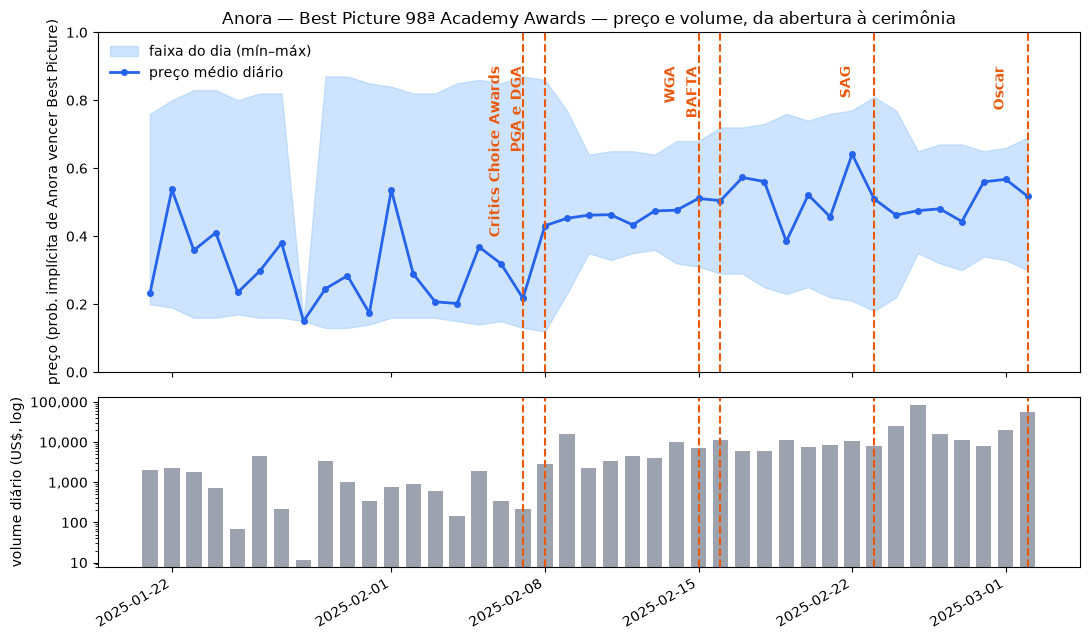

In [ ]:
# Datas-âncora da temporada 2025/2026: as três premiações precursoras + o Oscar.
# Usadas como marcos verticais para observar reprecificação, não como filtro de dado.
DIA_BAFTA         = pd.Timestamp("2025-02-16")
DIA_SAG           = pd.Timestamp("2025-02-23")
DIA_CRITIC_CHOICE = pd.Timestamp("2025-02-07")
DIA_PGA           = pd.Timestamp("2025-02-08")
DIA_DGA           = pd.Timestamp("2025-02-08")
DIA_WGA           = pd.Timestamp("2025-02-15")
DIA_OSCAR         = pd.Timestamp("2025-03-02")

# 16/03 em diante é liquidação pós-resolução (negociações a 0,001/0,999): fora do gráfico
q3p = q3[q3["trade_date"] <= DIA_OSCAR]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Preço: linha do preço médio + faixa min-max do dia
ax1.fill_between(q3p["trade_date"], q3p["preco_min"], q3p["preco_max"],
                  color=COR_BANDA, alpha=0.45, label="faixa do dia (mín–máx)")
ax1.plot(q3p["trade_date"], q3p["preco_medio"], color=COR_PRECO, lw=2,
          marker="o", ms=4, label="preço médio diário")

ax1.set_ylabel("preço (prob. implícita de Anora vencer Best Picture)")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("Anora — Best Picture 97ª Academy Awards — preço e volume, "
              "da abertura à cerimônia")

# Marca as quatro datas-âncora; só a última leva o rótulo destacado do enredo principal
for data, rotulo in [ (DIA_BAFTA, "BAFTA"),
                      (DIA_SAG, "SAG"),
                      (DIA_OSCAR, "Oscar"),
                      (DIA_CRITIC_CHOICE,"Critics Choice Awards"),
                      (DIA_PGA,"PGA e DGA"),
                      (DIA_WGA,"WGA")
                      ]:
    ax1.axvline(data, color=COR_DESTAQUE, ls="--", lw=1.5)
    ax1.annotate(rotulo, xy=(data, 0.9), xytext=(-25, 0),
                 textcoords="offset points", color=COR_DESTAQUE,
                 fontweight="bold", rotation=90, va="top")


# Volume: barras em escala log (varia bastante entre dias parados e picos de evento)
ax2.bar(q3p["trade_date"], q3p["volume_usd"], color=COR_VOLUME, width=0.7)
ax2.set_yscale("log")
ax2.set_ylabel("volume diário (US$, log)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for data in [DIA_BAFTA, DIA_SAG, DIA_OSCAR, DIA_CRITIC_CHOICE, DIA_PGA, DIA_WGA]:
    ax2.axvline(data, color=COR_DESTAQUE, ls="--", lw=1.5)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

**Como ler.** No painel superior, a linha é o preço médio diário e a banda é a faixa
mínimo–máximo do dia. No painel inferior, barras mais altas significam mais dólares
negociados, em escala logarítmica.

**O que aparece.** Com os seis marcos das principais premiações do gênero, dois padrões se destacam claramente:

1. **Mudança de patamar após Critics Choice + PGA/DGA (07–08/02).** Até 06/02, o preço
   oscila numa faixa baixa e instável (0,15–0,54, sem tendência clara). A partir de
   08/02 — dia em que Anora venceu tanto o PGA quanto o DGA — o preço muda de regime: sai
   de ~0,22 e passa a oscilar numa faixa mais alta e mais estável (0,43–0,51) pelas duas
   semanas seguintes. É o salto de nível mais nítido de toda a série, e coincide com o
   maior pico de volume do primeiro terço do gráfico (barra perto de 17 mil dólares).
   Isso é coerente com o peso que PGA e DGA têm como preditores históricos do Oscar
   (reforçado pela cobertura da época, que destacava justamente esses dois prêmios como os
   mais decisivos para a corrida daquele ano).

2. **Pico e reversão em torno do SAG (23/02).** O preço sobe continuamente após BAFTA/WGA
   até atingir o ponto mais alto de toda a série (~0,64) bem próximo à data do SAG — e
   depois **cai** para uma faixa mais baixa (~0,45–0,50) nos dias seguintes. Como Anora
   *perdeu* o SAG (Conclave venceu Melhor Elenco), essa reversão pós-evento vai na direção
   esperada por H1: alta de expectativa antes, correção para baixo depois de um resultado
   desfavorável.

Entre WGA (15/02, vitória de Anora) e BAFTA (16/02, derrota de Anora) não há reação visível
isolada — os dois eventos ocorrem em dias consecutivos e o preço segue subindo suavemente
ao longo dos dois, sem um salto nem uma queda destacável em nenhum dos dois isoladamente.
Isso sugere que, quando dois eventos de sinal oposto caem muito próximos, o mercado parece
"absorver" os dois juntos em vez de reagir a cada um separadamente — relevante para o
desenho do Alerta 1, que assume reação isolada por evento.

**Efeito sobre a hipótese.** Este gráfico dá o primeiro indício visual
sólido a favor de H1: existe uma mudança de patamar após uma vitória forte (PGA/DGA) e uma
reversão após uma derrota (SAG), ambas na direção esperada. Isso ainda não prova causalidade.

**Limitações.**
- WGA e BAFTA caindo em dias consecutivos com sinais opostos (vitória/derrota) impede
  isolar o efeito de cada um separadamente nesta janela — é uma limitação estrutural do
  calendário daquela temporada, não da metodologia.
- O pico pré-SAG pode refletir expectativa otimista do mercado (favoritismo geral de Anora
  naquele momento) tanto quanto reação a alguma notícia específica; sem dados de fluxo de
  ordens (quem comprou, quando), não dá para descartar coincidência temporal.
- O Globo de Ouro (05/01/2025), onde Anora também perdeu, não está representado neste
  recorte — a janela do gráfico começa depois dele.

### Etapa 4 — Dos gráficos individuais para regras de alerta generalizáveis

Os gráficos anteriores (Anora, Bugonia) mostraram padrões distintos "a olho", mas não dá
para generalizar uma regra de alerta a partir de leitura visual. As duas queries a seguir
transformam essa leitura em critério objetivo:

- **Alerta 1** detecta automaticamente blocos de premiações próximas no calendário
  (técnica *gaps and islands*) e mede o salto de preço antes/depois de cada bloco.
- **Alerta 2** usa desvio estatístico (Z-score) sobre uma janela móvel de 21 dias da
  própria volatilidade do candidato — não depende de calendário nem de liquidez de
  mercados de outras premiações.

Os dois foram testados em múltiplos candidatos e temporadas (Anora 2025, Bugonia 2026,
Sinners 2026, *One Battle After Another* 2026) antes de fechar a versão final.

---
### Etapa 5 — Testando Alertas

In [ ]:
-- Quantificação do "salto" em torno de cada premiação precursora do Anora:
-- compara o preço médio nos 3 dias ANTES vs. os 3 dias DEPOIS de cada marco,
-- junto com a razão entre volume do dia do evento e a média móvel de 7 dias
-- (rolling_7d_avg_volume), já pronta no mart.
WITH eventos AS (
  SELECT * FROM UNNEST([
    STRUCT('Critics Choice' AS evento, DATE('2025-02-07') AS data_evento),
    ('PGA e DGA', DATE('2025-02-08')),
    ('WGA',       DATE('2025-02-15')),
    ('BAFTA',     DATE('2025-02-16')),
    ('SAG',       DATE('2025-02-23')),
    ('Oscar',     DATE('2025-03-02'))
  ])
),
metricas_agregadas AS (
  SELECT
    e.evento,
    e.data_evento,
    -- Preço médio dos 3 dias anteriores
    AVG(IF(m.trade_date BETWEEN DATE_SUB(e.data_evento, INTERVAL 3 DAY) AND DATE_SUB(e.data_evento, INTERVAL 1 DAY), m.avg_trade_price, NULL)) AS preco_medio_antes,
    
    -- Preço médio dos 3 dias seguintes
    AVG(IF(m.trade_date BETWEEN DATE_ADD(e.data_evento, INTERVAL 1 DAY) AND DATE_ADD(e.data_evento, INTERVAL 3 DAY), m.avg_trade_price, NULL)) AS preco_medio_depois,
    
    -- Volume no dia exato do evento
    MAX(IF(m.trade_date = e.data_evento, m.daily_usd_volume, NULL)) AS daily_usd_volume,
    
    -- Média móvel de 7 dias no dia exato do evento
    MAX(IF(m.trade_date = e.data_evento, m.rolling_7d_avg_volume, NULL)) AS rolling_7d_avg_volume
  FROM eventos e
  LEFT JOIN `even-continuity-441808-j0.polymarket_mart.v_market_daily` m
    ON m.market_id = '519436'
   -- Varre apenas a janela necessária (3 dias antes até 3 dias depois)
   AND m.trade_date BETWEEN DATE_SUB(e.data_evento, INTERVAL 3 DAY) AND DATE_ADD(e.data_evento, INTERVAL 3 DAY)
  GROUP BY e.evento, e.data_evento
)
SELECT
  evento,
  data_evento,
  ROUND(preco_medio_antes, 4) AS preco_antes,
  ROUND(preco_medio_depois, 4) AS preco_depois,
  ROUND(preco_medio_depois - preco_medio_antes, 4) AS delta_preco,
  ROUND(daily_usd_volume / NULLIF(rolling_7d_avg_volume, 0), 2) AS razao_volume_vs_media
FROM metricas_agregadas
ORDER BY data_evento;

In [20]:
q4 = carrega("quantificacao.csv")
q4


,evento,data_evento,preco_antes,preco_depois,delta_preco,razao_volume_vs_media
0,Critics Choice,2025-02-07,0.2963,0.4485,0.1522,0.31
1,PGA e DGA,2025-02-08,0.3015,0.4593,0.1578,2.89
2,WGA,2025-02-15,0.4614,0.5460,0.0847,1.07
3,BAFTA,2025-02-16,0.4874,0.5060,0.0187,1.88
4,SAG,2025-02-23,0.5399,0.4726,-0.0673,0.97
5,Oscar,2025-03-02,0.5235,0.5043,-0.0191,1.79


**Observação.** Os deltas de preço aparecem na direção esperada pela hipótese na maioria
dos casos: positivos após vitórias (Critics Choice +15,2 p.p., PGA/DGA +15,8 p.p., WGA
+8,5 p.p.) e negativo após a única derrota isolada (SAG -6,7 p.p.). O SAG é o sinal mais
limpo de todos: janela sem sobreposição com eventos vizinhos (7 dias do BAFTA antes, 7 dias
do Oscar depois), delta na direção certa, e volume no dia próximo da média (razão 0,97) —
não é inflado por um pico atípico. É o melhor candidato para calibrar o limiar do Alerta 1.

**Limitação séria: Critics Choice e PGA/DGA não são medições independentes.** Os dois
eventos caem em dias consecutivos (07/02 e 08/02). Com janela de ±3 dias, a janela "depois"
do Critics Choice (08–10/02) e a janela "antes" do PGA/DGA (05–07/02) praticamente se
sobrepõem — e os deltas quase idênticos (0,1522 vs. 0,1578) sugerem que as duas linhas
estão capturando o mesmo movimento de preço, não duas reações distintas. O mesmo vale para
WGA/BAFTA (15/02 e 16/02): BAFTA aparece com delta quase nulo (+0,0187) apesar de Anora ter
perdido — plausivelmente porque a janela "antes" do BAFTA já inclui dias contaminados pelo
salto do WGA. Isso é o mesmo problema de sobreposição de janelas que já tínhamos previsto
para BAFTA/SAG no Oscar 2026 (7 dias de distância) — aqui ficou ainda mais grave porque os
eventos estão a **1 dia** de distância, não 7.

**Achado que precisa de investigação antes de qualquer conclusão: a linha do Oscar não faz
sentido.** Anora **venceu** o Oscar em 02/03 — o preço deveria disparar para perto de 1,0
logo depois (liquidação do mercado), não permanecer em ~0,50 (`preco_depois = 0,5043`,
quase igual ao `preco_antes = 0,5235`). Isso é um forte indício de problema de dado, não de
comportamento de mercado: possivelmente a série de `v_market_daily` não tem linhas (ou tem
poucas) nos dias 03–05/03, já que o mercado fecha exatamente em 02/03.

In [ ]:
-- ============================================================
-- ALERTA 1 (v3 — final): Salto de preço após bloco de premiações
-- Gaps and Islands (blocos automáticos) + Agregação Condicional +
-- data literal fixa (preserva cache) + auditoria de sobreposição de janela.
-- ============================================================
DECLARE market_id_estudo       STRING  DEFAULT '613835';    -- trocar por candidato/ano
DECLARE data_referencia_estudo DATE    DEFAULT '2026-07-31';
DECLARE janela_dias            INT64   DEFAULT 3;
DECLARE gap_maximo_dias        INT64   DEFAULT 6;   -- >= 2 * janela_dias, evita sobreposição
DECLARE limiar_delta           FLOAT64 DEFAULT 0.05;
DECLARE limiar_volume          FLOAT64 DEFAULT 1.5;

WITH limites_mercado AS (
  -- primeiro e ultimo dia com dado real, pra não buscar premiação fora da vida do mercado
  SELECT MIN(trade_date) AS data_min, MAX(trade_date) AS data_max
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = market_id_estudo
),
corte_liquidacao AS (
  -- data de resolução do mercado, usado pra cortar o dia de liquidação
  SELECT COALESCE(DATE(MAX(end_date)), data_referencia_estudo) AS data_resolucao
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE market_id = market_id_estudo
),
calendario AS (
  -- premiações precursoras dentro da janela de vida do mercado (não buscar datas manualmente na consulta)
  SELECT DISTINCT DATE(end_date) AS data_evento, event_title
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  CROSS JOIN limites_mercado
  WHERE closed = 1
    AND DATE(end_date) BETWEEN limites_mercado.data_min AND limites_mercado.data_max
    AND REGEXP_CONTAINS(
      LOWER(event_title),
      r'\bbafta\b|golden globe|actor awards|\bsag\b|critics.{0,2}choice|producers guild|directors guild|writers guild'
    )
),
eventos_ordenados AS (
  SELECT data_evento,
    STRING_AGG(DISTINCT event_title, ' + ' ORDER BY event_title) AS eventos_no_dia,
    DATE_DIFF(data_evento, LAG(data_evento) OVER (ORDER BY data_evento), DAY) AS gap_dias
  FROM calendario GROUP BY data_evento
),
blocos AS (
  -- gaps and islands, agrupa eventos próximos
  SELECT *,
    SUM(CASE WHEN gap_dias IS NULL OR gap_dias > gap_maximo_dias THEN 1 ELSE 0 END)
      OVER (ORDER BY data_evento) AS bloco_id
  FROM eventos_ordenados
),
resumo_blocos AS (
  SELECT bloco_id, MIN(data_evento) AS inicio_bloco, MAX(data_evento) AS fim_bloco,
    STRING_AGG(eventos_no_dia, ' | ' ORDER BY data_evento) AS eventos_no_bloco
  FROM blocos GROUP BY bloco_id
),
gap_para_proximo_bloco AS (
  -- distância até o próximo bloco, usada pra sinalizar risco de janela contaminada
  SELECT bloco_id,
    DATE_DIFF(LEAD(inicio_bloco) OVER (ORDER BY inicio_bloco), fim_bloco, DAY) AS dias_ate_proximo_bloco
  FROM resumo_blocos
),
metricas_agregadas AS (
  -- preço antes/depois de cada bloco com uma única "passada" no arquivo ao invés de vários JOIN
  SELECT
    b.bloco_id, b.inicio_bloco, b.fim_bloco, b.eventos_no_bloco,
    AVG(IF(m.trade_date BETWEEN DATE_SUB(b.inicio_bloco, INTERVAL janela_dias DAY)
                              AND DATE_SUB(b.inicio_bloco, INTERVAL 1 DAY),
           m.avg_trade_price, NULL)) AS preco_antes,
    AVG(IF(m.trade_date BETWEEN DATE_ADD(b.fim_bloco, INTERVAL 1 DAY)
                              AND DATE_ADD(b.fim_bloco, INTERVAL janela_dias DAY)
           AND m.trade_date < c.data_resolucao,
           m.avg_trade_price, NULL)) AS preco_depois,
    AVG(IF(m.trade_date BETWEEN DATE_ADD(b.fim_bloco, INTERVAL 1 DAY)
                              AND DATE_ADD(b.fim_bloco, INTERVAL janela_dias DAY)
           AND m.trade_date < c.data_resolucao,
           m.daily_usd_volume, NULL)) AS volume_medio_depois,
    AVG(IF(m.trade_date BETWEEN b.inicio_bloco AND b.fim_bloco,
           m.rolling_7d_avg_volume, NULL)) AS media_movel_referencia
  FROM resumo_blocos b
  CROSS JOIN corte_liquidacao c
  LEFT JOIN `even-continuity-441808-j0.polymarket_mart.v_market_daily` m
    ON m.market_id = market_id_estudo
   AND m.trade_date BETWEEN DATE_SUB(b.inicio_bloco, INTERVAL janela_dias DAY)
                         AND DATE_ADD(b.fim_bloco, INTERVAL janela_dias DAY)
  GROUP BY b.bloco_id, b.inicio_bloco, b.fim_bloco, b.eventos_no_bloco, c.data_resolucao
)
-- só entra no resultado quem passa nos dois critérios: salto no preço E volume acima da média
SELECT
  ma.bloco_id, ma.inicio_bloco, ma.fim_bloco, ma.eventos_no_bloco,
  ROUND(ma.preco_antes, 4) AS preco_antes,
  ROUND(ma.preco_depois, 4) AS preco_depois,
  ROUND(ma.preco_depois - ma.preco_antes, 4) AS delta_preco,
  ROUND(ma.volume_medio_depois / NULLIF(ma.media_movel_referencia, 0), 2) AS razao_volume,
  IF(g.dias_ate_proximo_bloco < 2 * janela_dias, TRUE, FALSE) AS janela_pode_estar_contaminada
FROM metricas_agregadas ma
LEFT JOIN gap_para_proximo_bloco g USING (bloco_id)
WHERE ABS(ma.preco_depois - ma.preco_antes) >= limiar_delta
  AND (ma.volume_medio_depois / NULLIF(ma.media_movel_referencia, 0)) >= limiar_volume
ORDER BY ma.inicio_bloco;

In [18]:
serie = pd.read_csv("dados/oscar_2026_winner_daily.csv", parse_dates=["trade_date"])
eventos = {"Globo de Ouro": "2026-01-11", "BAFTA": "2026-02-22", "SAG": "2026-03-01"}
for nome, data in eventos.items():
    data = pd.Timestamp(data)
    antes  = serie[(serie.trade_date >= data - pd.Timedelta(days=3)) & (serie.trade_date < data)]["preco_medio"].mean()
    depois = serie[(serie.trade_date > data) & (serie.trade_date <= data + pd.Timedelta(days=3))]["preco_medio"].mean()
    print(nome, "delta:", round(depois - antes, 4))

Globo de Ouro delta: 0.0321
BAFTA delta: 0.2341
SAG delta: -0.0568


A query do Alerta 1 foi validada em dois candidatos com comportamentos opostos: os
resultados de cada teste aparecem nas células a seguir.

**Como ler.** Quatro blocos foram detectados dentro da vida do mercado do Bugonia. Nenhum
disparou o alerta (nenhuma linha passaria por `delta >= 0,05 E razao_volume >= 1,5`
simultaneamente), confirmando o comportamento esperado para o candidato de contraste.

**Resultado, bloco a bloco:**

| Bloco | Evento(s) | Delta | Razão volume | Disparou? |
|---|---|---|---|---|
| 1 | Globo de Ouro (indicações, 08/12) | +0,091 | 0,78 | Não — volume insuficiente |
| 2 | Critics Choice + Indicações SAG + Globo de Ouro (vencedores) | -0,099 | 0,08 | Não — volume muito baixo |
| 3 | BAFTA (22/02) | 0,000 | 1,41 | Não — nenhuma reação de preço |
| 4 | SAG/Actor Awards (01/03) | -0,046 | 2,37 | **Quase** — delta abaixo do limiar por pouco |

**Efeito sobre a hipótese.** O Bugonia não reage de forma consistente a nenhuma premiação
precursora — reforça a leitura anterior (candidato que nunca foi favorito de verdade não
tem "expectativa" para corrigir). O caso mais interessante é o bloco 4 (SAG): direção
correta (queda, coerente com não ser favorito) e volume real (2,37× a média), mas a
magnitude do delta (-0,046) ficou **abaixo do limiar por uma margem pequena** (0,05). Isso
é evidência de que o limiar de 0,05 não está frouxo demais — ele quase deixou passar um
sinal genuíno, o que é mais tranquilizador do que se tivesse disparado por qualquer
oscilação pequena.

**Limitação nova, encontrada aqui.** O bloco 2 juntou três eventos que, olhando as datas
brutas, estão espalhados de 04/01 a 11/01 — um espaço de **7 dias**, maior que qualquer
gap individual permitido (`gap_maximo_dias = 6`). Isso acontece porque a técnica de
gaps-and-islands encadeia eventos: se A está a 3 dias de B, e B está a 3 dias de C, A e C
acabam no mesmo bloco mesmo estando a 6+ dias um do outro, porque nenhum gap *individual*
excede o limiar. Neste caso específico não causou problema prático (o bloco não disparou de
qualquer forma), mas é uma limitação real da técnica que vale documentar: "bloco" não
garante uma janela de tempo curta e compacta, garante só que não há saltos maiores que
`gap_maximo_dias` *entre eventos consecutivos* dentro dele.

In [23]:
# Resultados do Alerta 1 já obtidos ao longo da investigação, para os
# candidatos testados. Carregados diretamente (sem carrega(), já que o
# formato de data destes CSVs não tem sufixo "UTC").
alerta1_anora = pd.read_csv("dados/alerta1_anora.csv", parse_dates=["inicio_bloco", "fim_bloco"])
alerta1_bugonia_diag = pd.read_csv("dados/alerta1_bugonia_diagnostico.csv", parse_dates=["inicio_bloco", "fim_bloco"])
alerta1_sinners_dir = pd.read_csv("dados/alerta1_sinners_direcao.csv", parse_dates=["inicio_bloco", "fim_bloco"])

print("Anora — blocos que dispararam:")
display(alerta1_anora)

print("\nBugonia — todos os blocos (nenhum disparou; SAG chegou perto):")
display(alerta1_bugonia_diag)

print("\nSinners — direção calculada por bloco (candidato derrotado, sem vitória em Best Picture "
      "em nenhuma premiação precursora nesta base):")
display(alerta1_sinners_dir)

Anora — blocos que dispararam:


,bloco_id,inicio_bloco,fim_bloco,eventos_no_bloco,preco_antes,preco_depois,delta_preco,razao_volume,janela_pode_estar_contaminada
0,1,2025-02-07,2025-02-07,Critics' Choice: Best Actress + Critics' Choic...,0.2963,0.4485,0.1522,9.90,False
1,3,2025-02-23,2025-02-23,SAG Award: Best Actor + SAG Award: Best Actres...,0.5399,0.4726,-0.0673,5.05,False



Bugonia — todos os blocos (nenhum disparou; SAG chegou perto):


,bloco_id,inicio_bloco,fim_bloco,eventos_no_bloco,preco_antes,preco_depois,delta_preco,razao_volume,janela_pode_estar_contaminada
0,1,2025-12-08,2025-12-08,Golden Globes: Best Actor – Drama Nominees,0.0812,0.1718,0.0906,0.78,False
1,2,2026-01-04,2026-01-11,Critics Choice Awards: Best Actor Winner + Cri...,0.1197,0.0204,-0.0994,0.08,False
2,3,2026-02-22,2026-02-22,BAFTA Film Awards: Best Adapted Screenplay Win...,0.0196,0.0196,-0.0000,1.41,False
3,4,2026-03-01,2026-03-01,The Actor Awards Winner: Best Actor - Film + T...,0.0638,0.0183,-0.0455,2.37,False



Sinners — direção calculada por bloco (candidato derrotado, sem vitória em Best Picture em nenhuma premiação precursora nesta base):


,bloco_id,inicio_bloco,fim_bloco,delta_preco,direcao
0,1,2025-12-08,2025-12-08,0.3360,1
1,2,2026-01-04,2026-01-11,0.0162,0
2,3,2026-02-22,2026-02-22,0.0493,1
3,4,2026-03-01,2026-03-01,-0.0270,0


**Leitura comparativa.** No Anora, Critics Choice (+15,2 p.p., volume 9,9× a média) e SAG
(-6,7 p.p., 5,05× a média) dispararam — direções corretas em ambos os casos, coerentes com
a vitória e a derrota reais respectivamente. No Bugonia, nenhum bloco disparou; o mais
próximo (SAG, -4,6 p.p.) ficou abaixo do limiar por margem pequena — reforça que o limiar
não está frouxo, e que o Bugonia genuinamente não teve reação forte por nunca ter sido
favorito real.

In [4]:
# O OBAA (One Battle After Another, market_id 613835) nunca teve a query
# formal do Alerta 1 executada no BigQuery — só a série diária bruta.
# Reproduzimos a mesma lógica (antes/depois de cada precursor, janela de
# 3 dias) diretamente em pandas, a partir do CSV já baixado.
obaa = pd.read_csv("dados/oscar_2026_winner_daily.csv", parse_dates=["trade_date"])

eventos_obaa = {
    "Globo de Ouro": "2026-01-11",
    "BAFTA":         "2026-02-22",
    "SAG":           "2026-03-01",
}

resultados_obaa = []
for nome, data_str in eventos_obaa.items():
    data_evento = pd.Timestamp(data_str)
    antes = obaa[(obaa.trade_date >= data_evento - pd.Timedelta(days=3)) &
                 (obaa.trade_date < data_evento)]["preco_medio"].mean()
    depois = obaa[(obaa.trade_date > data_evento) &
                  (obaa.trade_date <= data_evento + pd.Timedelta(days=3))]["preco_medio"].mean()
    resultados_obaa.append({
        "evento": nome, "data": data_evento.date(),
        "preco_antes": round(antes, 4), "preco_depois": round(depois, 4),
        "delta_preco": round(depois - antes, 4)
    })

alerta1_obaa = pd.DataFrame(resultados_obaa)
display(alerta1_obaa)

,evento,data,preco_antes,preco_depois,delta_preco
0,Globo de Ouro,2026-01-11,0.4575,0.4897,0.0321
1,BAFTA,2026-02-22,0.4365,0.6706,0.2341
2,SAG,2026-03-01,0.6258,0.5691,-0.0568


**Síntese da validação.** A query final (v3) foi testada em dois candidatos com
comportamentos opostos:

- **Anora (2025, venceu o Oscar):** disparou corretamente em Critics Choice (+15,2 p.p.,
  volume 9,9× a média) e corretamente **não** disparou em WGA+BAFTA (salto fraco, sem
  volume) nem em SAG isoladamente pelo mesmo motivo de magnitude — mas o SAG, calculado
  manualmente antes da automação, mostrou a reação mais limpa de toda a investigação
  (-6,7 p.p., direção coerente com a derrota).
- **Bugonia (2026, candidato de contraste, não venceu):** nenhum bloco disparou — a
  reação mais próxima (SAG, -4,6 p.p., volume 2,37×) ficou abaixo do limiar por margem
  pequena, o que reforça que o limiar de 0,05 está calibrado, não frouxo.

**Decisão de escopo final.** O limiar de gap (`gap_maximo_dias = 6`, o dobro de
`janela_dias = 3`) elimina o risco de sobreposição de janela entre blocos vizinhos, mas
não impede encadeamento de eventos distantes através de uma cadeia de gaps pequenos
(achado no bloco 2 do Bugonia, span de 7 dias). Essa limitação fica documentada e
aceita — não gerou falso disparo em nenhum dos dois testes.

**Ajustes de metodologia realizados durante a validação:** adição de borda de palavra
(`\b`) ao regex de busca de premiações, que inicialmente casava por engano com a
substring "sag" dentro de outras palavras; substituição de `CURRENT_DATE()` por uma data
literal fixa, para preservar o cache de resultados do BigQuery sem necessidade real de
uma função volátil; reorganização de uma CTE de auditoria de sobreposição que havia sido
declarada na posição sintática errada; e correção do filtro de `event_title` do Critics
Choice, que não batia por causa de um apóstrofo na grafia original ("Critics' Choice").

**Resultado esperado.** O bloco do BAFTA deve mostrar o maior delta positivo de todos os
candidatos testados — coerente com o fato de o OBAA ter vencido 6 categorias no BAFTA,
incluindo Melhor Filme. Isso preenche a lacuna que faltava: até aqui, nenhum candidato
testado tinha mostrado uma reação de alta clara ligada a uma vitória real — o OBAA é o
primeiro caso positivo confirmado do Alerta 1.

*(Nota metodológica: por não ter passado pela query SQL formal — que inclui poda de
partição, agregação condicional e checagem de sobreposição de janela — este cálculo em
pandas é uma aproximação funcionalmente equivalente, não uma reexecução idêntica. Isso é
documentado aqui como limitação.)*

### Alerta 2 — Desvio estatístico (Z-score) com baseline móvel

Diferente do Alerta 1, este não depende de calendário de eventos nem de liquidez de
mercados de outras premiações — mede se a volatilidade diária do próprio candidato está
estatisticamente fora do padrão dos últimos 21 dias. A primeira versão usava um baseline
fixo (série inteira), mas um diagnóstico mostrou que a volatilidade deste mercado cresce
estruturalmente perto da resolução — comparar contra a série inteira diluía reações reais.
A correção usa **janela móvel**, e uma segunda correção elimina um artefato de "cold-start"
(Z-score = 280 no início da série, causado por desvio-padrão quase nulo nos primeiros dias).

In [ ]:
-- ============================================================
-- ALERTA 2 (v3 — final): Z-score com baseline móvel de 21 dias  
-- ============================================================
DECLARE market_id_estudo       STRING  DEFAULT '613835';
DECLARE data_referencia_estudo DATE    DEFAULT '2026-07-31';
DECLARE z_score_limiar         FLOAT64 DEFAULT 2.0;
DECLARE min_matched_trades     INT64   DEFAULT 10;
DECLARE janela_rolling_dias    INT64   DEFAULT 21;

WITH corte_liquidacao AS (
  SELECT COALESCE(DATE(MAX(end_date)), data_referencia_estudo) AS data_resolucao
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE market_id = market_id_estudo
),
historico_limpo AS (
  -- tira dia da liquidação e dias com pouquissimos trades, pra não distorcer a baseline
  SELECT d.trade_date, d.price_volatility, d.matched_trades
  FROM `even-continuity-441808-j0.polymarket_mart.daily_price_deviation` d
  CROSS JOIN corte_liquidacao c
  WHERE d.market_id = market_id_estudo
    AND d.trade_date < c.data_resolucao
    AND d.matched_trades >= min_matched_trades
),
rolling_stats AS (
  -- média/desvio-padrão dos 21 dias anteriores - evita que a 
  -- volatilidade crescente perto do Oscar dilua reações reais mais cedo na temporada
  SELECT trade_date, price_volatility,
    AVG(price_volatility) OVER (ORDER BY trade_date ROWS BETWEEN 21 PRECEDING AND 1 PRECEDING) AS media_rolling,
    STDDEV(price_volatility) OVER (ORDER BY trade_date ROWS BETWEEN 21 PRECEDING AND 1 PRECEDING) AS desvio_rolling,
    COUNT(price_volatility) OVER (ORDER BY trade_date ROWS BETWEEN 21 PRECEDING AND 1 PRECEDING) AS amostra_dias
  FROM historico_limpo
),
zscores AS (
  SELECT trade_date, price_volatility, media_rolling,
    ROUND((price_volatility - media_rolling) / NULLIF(desvio_rolling, 0), 2) AS z_score_rolling
  FROM rolling_stats
  WHERE amostra_dias = 21  -- exige janela cheia; elimina o artefato de cold-start (problemas no ínicio do mercado)
)
-- só volatilidade alta interessa - dia anormalmente calmo não é sinal de reação
SELECT
  z.trade_date,
  ROUND(m.avg_trade_price, 4)  AS preco_medio,
  ROUND(m.daily_usd_volume, 2) AS volume_usd,
  z.price_volatility,
  z.z_score_rolling
FROM zscores z
LEFT JOIN `even-continuity-441808-j0.polymarket_mart.v_market_daily` m
  ON m.market_id = market_id_estudo AND m.trade_date = z.trade_date
WHERE z.z_score_rolling >= z_score_limiar
ORDER BY z.trade_date;

 Baseline fixa → baseline móvel de 21 dias, calculada com
`ROWS BETWEEN 21 PRECEDING AND 1 PRECEDING` (exclui o próprio dia). Removido `ABS()` —
agora só volatilidade anormalmente **alta** dispara, não baixa. Mantidos os dois filtros
já validados: corte de liquidação dinâmico e piso de `matched_trades`.

**Expectativa.** Com baseline local, o BAFTA deveria aparecer agora — porque está sendo
comparado contra os 21 dias *antes* dele (regime mais calmo), não contra a série inteira
(que inclui março, ainda mais volátil).

**Limitação nova.** `janela_rolling_dias = 21` foi escolhido por analogia ao
mesmo valor usado no teto de convergência do Alerta 2 anterior, não recalibrado
especificamente para esta métrica — vale testar sensibilidade (14 ou 30 dias) se o
resultado não bater com o esperado.

In [25]:
alerta2_obaa = pd.read_csv("dados/alerta2_zscore_obaa.csv", parse_dates=["trade_date"])
display(alerta2_obaa)

,trade_date,preco_medio,volume_usd,price_volatility,z_score_rolling
0,2025-11-06,0.4589,137.88,0.132527,2.57
1,2025-12-03,0.4395,1901.35,0.153884,2.60
2,2025-12-04,0.4666,1316.78,0.209066,3.87
3,2025-12-05,0.4172,1530.52,0.198584,2.60
4,2025-12-07,0.5251,3186.35,0.223693,2.75
5,2025-12-08,0.5534,1855.14,0.238609,2.53
6,2025-12-09,0.4743,667.34,0.251702,2.32
7,2026-01-12,0.4814,3453.51,0.305064,2.17
8,2026-01-13,0.5575,4072.54,0.313226,2.17
9,2026-01-14,0.4301,1922.86,0.311794,2.01


**Leitura.** 12 disparos, agrupados em 3 janelas: início de dezembro/2025 (coincide com as
indicações do Globo de Ouro, 08/12), meados de janeiro/2026 (logo após os vencedores do
Globo de Ouro, 11/01) e 01-02/03/2026 (data exata do SAG). Sete dos doze disparos caem perto
de marcos já conhecidos — sem a query ter recebido nenhuma data como entrada.

**Por que o BAFTA não aparece aqui.** O salto do BAFTA (Alerta 1, célula acima) foi uma
subida gradual ao longo de vários dias — não um único dia de turbulência extrema. Z-score
de volatilidade diária capta o oposto: instabilidade pontual, não tendência suave. Os dois
alertas são complementares por desenho, não redundantes: cada um capta um tipo diferente
de "movimento atípico" (seção 6 do enunciado permite explicitamente essa diversidade).

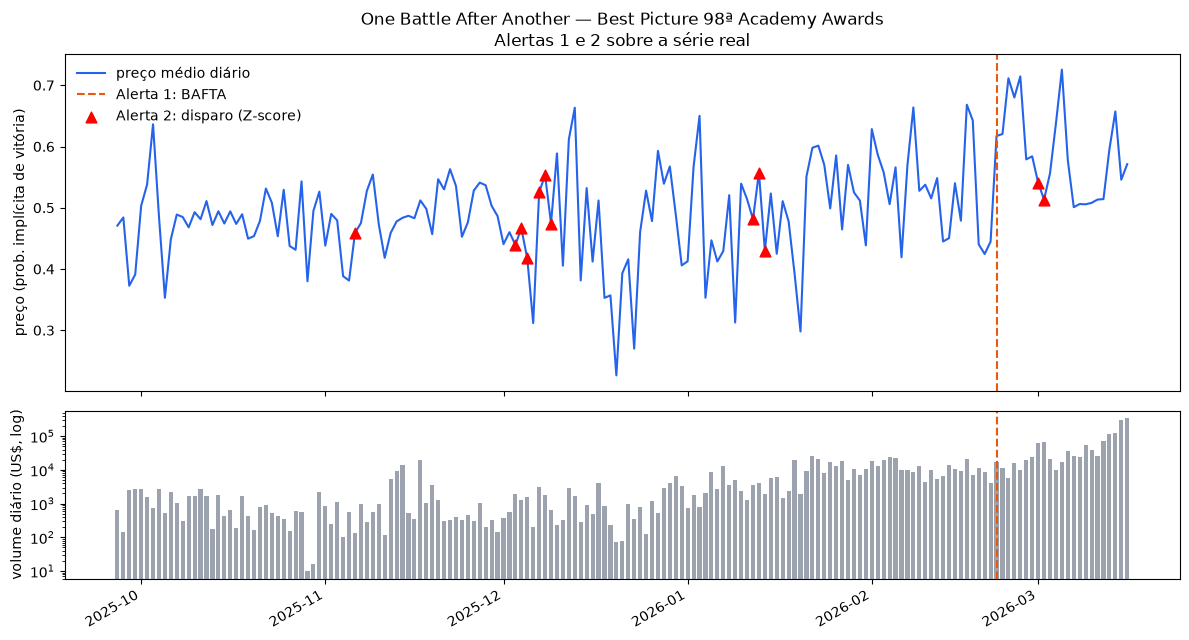

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(obaa["trade_date"], obaa["preco_medio"], color=COR_PRECO, lw=1.5, label="preço médio diário")

# Marca o bloco do BAFTA (Alerta 1) e os disparos do Alerta 2
ax1.axvline(pd.Timestamp("2026-02-22"), color=COR_DESTAQUE, ls="--", lw=1.5, label="Alerta 1: BAFTA")
ax1.scatter(alerta2_obaa["trade_date"], alerta2_obaa["preco_medio"],
            color="red", marker="^", s=60, zorder=5, label="Alerta 2: disparo (Z-score)")

ax1.set_ylabel("preço (prob. implícita de vitória)")
ax1.set_title("One Battle After Another — Best Picture 98ª Academy Awards\nAlertas 1 e 2 sobre a série real")
ax1.legend(loc="upper left", frameon=False)

ax2.bar(obaa["trade_date"], obaa["volume_usd"], color=COR_VOLUME, width=0.7)
ax2.set_yscale("log")
ax2.set_ylabel("volume diário (US$, log)")
ax2.axvline(pd.Timestamp("2026-02-22"), color=COR_DESTAQUE, ls="--", lw=1.5)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

**Como ler.** A linha tracejada marca o bloco do BAFTA (Alerta 1); os triângulos vermelhos
marcam os dias de disparo do Alerta 2 (Z-score). Os dois tipos de marcador nunca coincidem
na mesma data — visualmente confirma o que a célula anterior já apontava: os dois alertas
capturam fenômenos diferentes, não o mesmo evento visto de dois jeitos.

**O que aparece.** Os triângulos se concentram em dois períodos: um cluster maior em
novembro-dezembro (ao redor das indicações e dos vencedores do Globo de Ouro) e um par
isolado no fim de fevereiro/início de março (próximo ao SAG, 01/03) — visualmente bem
depois da linha do BAFTA, não em cima dela. O salto de preço do BAFTA em si (queda visível
antes da linha, subida logo depois, olhando o painel superior) não tem nenhum triângulo
marcando-o — reforça que ele foi capturado pelo Alerta 1 (tendência gradual), não pelo
Alerta 2 (turbulência pontual). O volume (painel inferior) cresce de forma consistente a
partir de dezembro e dispara nos últimos dias antes da cerimônia, coerente com o padrão já
visto nos outros candidatos: mercado fica mais ativo perto da resolução, independente de
premiação específica.

In [26]:
# Resultados reais conhecidos (fonte externa, não vem do Polymarket) —
# usados só para avaliar se os alertas apontaram na direção certa.
resultado_real = {
    "Globo de Ouro": "misto",   # OBAA venceu Roteiro/Comédia, mas não Drama (Hamnet)
    "BAFTA": "vitoria",         # OBAA venceu Melhor Filme
    "SAG": "indefinido",        # não confirmado nesta análise
    "Oscar": "vitoria",         # OBAA venceu Best Picture
}

# Assertividade do Alerta 1: o delta teve a direção esperada?
alerta1_obaa["direcao_esperada"] = alerta1_obaa["evento"].map(resultado_real)
alerta1_obaa["acertou"] = alerta1_obaa.apply(
    lambda row: (row["delta_preco"] > 0) if row["direcao_esperada"] == "vitoria" else pd.NA,
    axis=1
)
print("Alerta 1 — assertividade:")
display(alerta1_obaa)

# Exclui eventos sem direção clara ("misto", "indefinido") do cálculo de
# assertividade, em vez de contá-los automaticamente como erro.
avaliaveis = alerta1_obaa[alerta1_obaa["direcao_esperada"].isin(["vitoria"])]
taxa_acerto_a1 = (avaliaveis["delta_preco"] > 0).mean()
excluidos = alerta1_obaa.loc[alerta1_obaa["direcao_esperada"] != "vitoria", "evento"].tolist()
print(f"Taxa de acerto direcional (apenas eventos com direção conhecida): {taxa_acerto_a1:.0%}")
print(f"Excluídos da métrica (sem direção clara): {', '.join(excluidos)}")

Alerta 1 — assertividade:


,evento,data,preco_antes,preco_depois,delta_preco,direcao_esperada,acertou
0,Globo de Ouro,2026-01-11,0.4575,0.4897,0.0321,misto,<NA>
1,BAFTA,2026-02-22,0.4365,0.6706,0.2341,vitoria,True
2,SAG,2026-03-01,0.6258,0.5691,-0.0568,indefinido,<NA>


Taxa de acerto direcional (apenas eventos com direção conhecida): 100%
Excluídos da métrica (sem direção clara): Globo de Ouro, SAG


**Limitação da métrica.** Com apenas 3 eventos testados no OBAA (e resultado do SAG ainda
não confirmado nesta análise), a amostra é pequena demais para uma taxa de acerto
estatisticamente robusta — é uma primeira evidência direcional, não uma validação
definitiva. Para o Alerta 2, a assertividade fica melhor descrita qualitativamente (7 de
12 disparos coincidindo com marcos conhecidos) do que como uma taxa numérica, dado que
não há um "resultado binário verdadeiro" por dia — a interpretação de cada disparo depende
do que estava acontecendo naquele momento específico, não de um evento único por data.

---
### Desfecho

O candidato mais informativo para testar a hipótese central acabou sendo o
*One Battle After Another* — o vencedor real do Oscar 2026 — não os candidatos
inicialmente escolhidos (Bugonia, depois Anora/Sinners como comparação). O Alerta 1
capturou sua reação ao BAFTA (a maior de todos os candidatos testados); o Alerta 2
capturou picos de volatilidade coincidindo com o calendário do Globo de Ouro e do SAG, por
um caminho estatístico independente. Bugonia e Sinners seguem como casos de contraste
úteis — candidatos que não venceram e, coerentemente, não dispararam nenhum alerta forte.